# 06 — Multi-seed evaluation and learning curves

**Goal.** Once all three baselines have been trained across multiple seeds, this notebook produces the publication artefacts:

1. Per-algorithm mean ± 95 % bootstrap CI.
2. Pairwise Welch's t-tests between algorithms.
3. Learning curves (mean across seeds with SEM band).

## Statistical method (for the paper Methods section)

**95 % bootstrap CI** — non-parametric, 10 000 resamples with replacement from the per-episode return distribution. Justified because per-seed returns are not Gaussian (long-tailed failures).

**Welch's t-test** (two-sided, unequal variance):

$$ t = \frac{\bar{x}_A - \bar{x}_B}{\sqrt{s^2_A/n_A + s^2_B/n_B}} $$

Reported alongside $p$-value at $\alpha = 0.05$. We deliberately avoid Student's $t$ because the variance of off-policy methods (SAC) is empirically larger than on-policy (PPO) — equal-variance is the wrong null.

## Bug log

| # | Issue | Diagnosis | Fix |
|---|---|---|---|
| 1 | `evaluate.py` failed to load SAC model on MPS-only machine | `Algo.load(..., device='mps')` chokes when weights were saved on CPU + tensor types mismatch | Always evaluate on CPU (`device='cpu'`); MPS is for training only |
| 2 | Learning curves were ragged for the first 50 k steps | Different seeds finished different numbers of episodes by step 50 k → no aligned x-axis | Bin `cum_timesteps` into 200 buckets, then aggregate mean ± SEM per bucket |

## 6.1 Path setup + sanity check that runs exist

In [1]:
# Pre-flight cleanup — self-contained so it can run in any cell position.
# Removes:
#   (1) any duplicate seed-0 ppo_dr directories (the older one from prior fix attempts)
#   (2) any SAC smoke run (wallclock < 120 s = not real training)
import sys, shutil, json, pathlib

_PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(_PY_ROOT) not in sys.path:
    sys.path.insert(0, str(_PY_ROOT))
_RUNS = _PY_ROOT / 'runs'

# (1) Duplicate ppo_dr seed 0 — keep newest, drop older
dups = sorted(_RUNS.glob('ppo_dr__LunarLander-v3__seed0__*'),
              key=lambda p: p.stat().st_mtime)
for d in dups[:-1]:
    print(f'[cleanup] removing duplicate ppo_dr seed 0: {d.name}')
    shutil.rmtree(d)

# (2) SAC smoke run — anything finishing in <120 s
for d in _RUNS.glob('sac__*'):
    meta = d / 'run_meta.json'
    if meta.exists():
        wc = json.loads(meta.read_text()).get('wallclock_seconds', 0)
        if wc < 120:
            print(f'[cleanup] removing sac smoke ({wc:.0f}s): {d.name}')
            shutil.rmtree(d)

n_runs = sum(1 for _ in _RUNS.iterdir())
print(f'\n[cleanup] {n_runs} runs remaining on disk')
for d in sorted(_RUNS.iterdir()):
    algo = d.name.split('__')[0]
    print(f'  {algo:7s} {d.name}')


[cleanup] 20 runs remaining on disk
  ppo     ppo__LunarLander-v3__seed0__20260621T091157Z
  ppo     ppo__LunarLander-v3__seed1__20260621T091339Z
  ppo     ppo__LunarLander-v3__seed2__20260621T091607Z
  ppo     ppo__LunarLander-v3__seed3__20260621T091830Z
  ppo     ppo__LunarLander-v3__seed4__20260621T092058Z
  ppo_dr  ppo_dr__LunarLander-v3__seed0__20260621T102903Z
  ppo_dr  ppo_dr__LunarLander-v3__seed1__20260621T103147Z
  ppo_dr  ppo_dr__LunarLander-v3__seed2__20260621T103504Z
  ppo_dr  ppo_dr__LunarLander-v3__seed3__20260621T103824Z
  ppo_dr  ppo_dr__LunarLander-v3__seed4__20260621T104137Z
  q_learning q_learning__LunarLander-v3__seed0
  q_learning q_learning__LunarLander-v3__seed1
  q_learning q_learning__LunarLander-v3__seed2
  q_learning q_learning__LunarLander-v3__seed3
  q_learning q_learning__LunarLander-v3__seed4
  sac     sac__LunarLanderContinuous-v3__seed0__20260621T131608Z
  sac     sac__LunarLanderContinuous-v3__seed1__20260621T134126Z
  sac     sac__LunarLanderContinu

*We list every directory under `runs/` so we can confirm what's on disk before evaluation — protects against stale notebook outputs that reference deleted or renamed runs.*

In [2]:
import sys, pathlib
PY_ROOT = pathlib.Path('..').resolve() / 'py'
if str(PY_ROOT) not in sys.path:
    sys.path.insert(0, str(PY_ROOT))

RUNS = PY_ROOT / 'runs'
runs_present = sorted(p.name for p in RUNS.iterdir()) if RUNS.exists() else []
print(f'{len(runs_present)} runs found:')
for r in runs_present[:10]:
    print(f'  {r}')
if not runs_present:
    raise RuntimeError('No runs to evaluate. Train baselines first (notebooks 03/04/05).')

20 runs found:
  ppo__LunarLander-v3__seed0__20260621T091157Z
  ppo__LunarLander-v3__seed1__20260621T091339Z
  ppo__LunarLander-v3__seed2__20260621T091607Z
  ppo__LunarLander-v3__seed3__20260621T091830Z
  ppo__LunarLander-v3__seed4__20260621T092058Z
  ppo_dr__LunarLander-v3__seed0__20260621T102903Z
  ppo_dr__LunarLander-v3__seed1__20260621T103147Z
  ppo_dr__LunarLander-v3__seed2__20260621T103504Z
  ppo_dr__LunarLander-v3__seed3__20260621T103824Z
  ppo_dr__LunarLander-v3__seed4__20260621T104137Z


## 6.2 Nominal evaluation (no fault, no DR)

This is the apples-to-apples comparison: how well does each policy do on the *training distribution*?

*We run `evaluate.py` against every run with 50 deterministic episodes per seed, producing per-seed means and per-algorithm aggregates with episode-level and seed-level 95 % bootstrap CIs, plus the pairwise statistical battery (Welch's t, Mann-Whitney U, Cliff's δ, BH-corrected p-values).*

In [3]:
import subprocess, sys
cmd = [
    sys.executable, '-m', 'src.evaluate',
    '--runs', 'runs/ppo__*', 'runs/sac__*', 'runs/ppo_dr__*',
    '--n-episodes', '50',
    '--out', 'logs/eval_nominal.csv',
]
print('$', ' '.join(cmd))
result = subprocess.run(cmd, cwd=PY_ROOT, capture_output=True, text=True)
print(result.stdout[-3000:])

$ /opt/anaconda3/envs/thesis-py311/bin/python -m src.evaluate --runs runs/ppo__* runs/sac__* runs/ppo_dr__* --n-episodes 50 --out logs/eval_nominal.csv
[eval] ppo     ppo__LunarLander-v3__seed0__20260621T091157Z                 mean=  250.03  std=  22.02
[eval] ppo     ppo__LunarLander-v3__seed1__20260621T091339Z                 mean=  263.66  std=  22.04
[eval] ppo     ppo__LunarLander-v3__seed2__20260621T091607Z                 mean=  244.59  std=  38.37
[eval] ppo     ppo__LunarLander-v3__seed3__20260621T091830Z                 mean=  264.36  std=  21.52
[eval] ppo     ppo__LunarLander-v3__seed4__20260621T092058Z                 mean=  258.58  std=  19.78
[eval] sac     sac__LunarLanderContinuous-v3__seed0__20260621T131608Z       mean=  260.40  std=  44.85
[eval] sac     sac__LunarLanderContinuous-v3__seed1__20260621T134126Z       mean=  272.44  std=  39.72
[eval] sac     sac__LunarLanderContinuous-v3__seed2__20260621T135957Z       mean=  266.86  std=  21.77
[eval] sac     sac__Luna

## 6.3 Distribution-shift evaluation — step fault @ t=200, 50 % thrust loss

This is the central thesis question. *Without* any adaptation mechanism, how much does each baseline degrade?

*We re-run `evaluate.py` with the actuator-fault wrapper enabled. This is the central thesis question — how much does each baseline degrade when its actuators change mid-episode, with no prior warning to the policy?*

In [4]:
cmd = [
    sys.executable, '-m', 'src.evaluate',
    '--runs', 'runs/ppo__*', 'runs/sac__*', 'runs/ppo_dr__*',
    '--n-episodes', '50',
    '--fault-step', '200', '--fault-gain', '0.5',
    '--out', 'logs/eval_fault_t200_g0.5.csv',
]
print('$', ' '.join(cmd))
result = subprocess.run(cmd, cwd=PY_ROOT, capture_output=True, text=True)
print(result.stdout[-3000:])

$ /opt/anaconda3/envs/thesis-py311/bin/python -m src.evaluate --runs runs/ppo__* runs/sac__* runs/ppo_dr__* --n-episodes 50 --fault-step 200 --fault-gain 0.5 --out logs/eval_fault_t200_g0.5.csv
[eval] ppo     ppo__LunarLander-v3__seed0__20260621T091157Z                 mean=   64.86  std=  94.80
[eval] ppo     ppo__LunarLander-v3__seed1__20260621T091339Z                 mean=  165.11  std= 118.81
[eval] ppo     ppo__LunarLander-v3__seed2__20260621T091607Z                 mean=   37.75  std=  75.30
[eval] ppo     ppo__LunarLander-v3__seed3__20260621T091830Z                 mean=   78.15  std= 102.83
[eval] ppo     ppo__LunarLander-v3__seed4__20260621T092058Z                 mean=   67.44  std=  86.40
[eval] sac     sac__LunarLanderContinuous-v3__seed0__20260621T131608Z       mean=  263.01  std=  62.05
[eval] sac     sac__LunarLanderContinuous-v3__seed1__20260621T134126Z       mean=  266.98  std=  56.04
[eval] sac     sac__LunarLanderContinuous-v3__seed2__20260621T135957Z       mean=  24

## 6.4 Learning curves

*We invoke `plot_results.py` to read every Monitor CSV and produce a single seaborn figure with mean ± 95 % CI bands per algorithm — the headline learning-curves figure for the supervisor demo.*

$ /opt/anaconda3/envs/thesis-py311/bin/python scripts/plot_results.py --runs-root runs/ --out logs/learning_curves.png --smooth 50
[plot] saved → logs/learning_curves.png


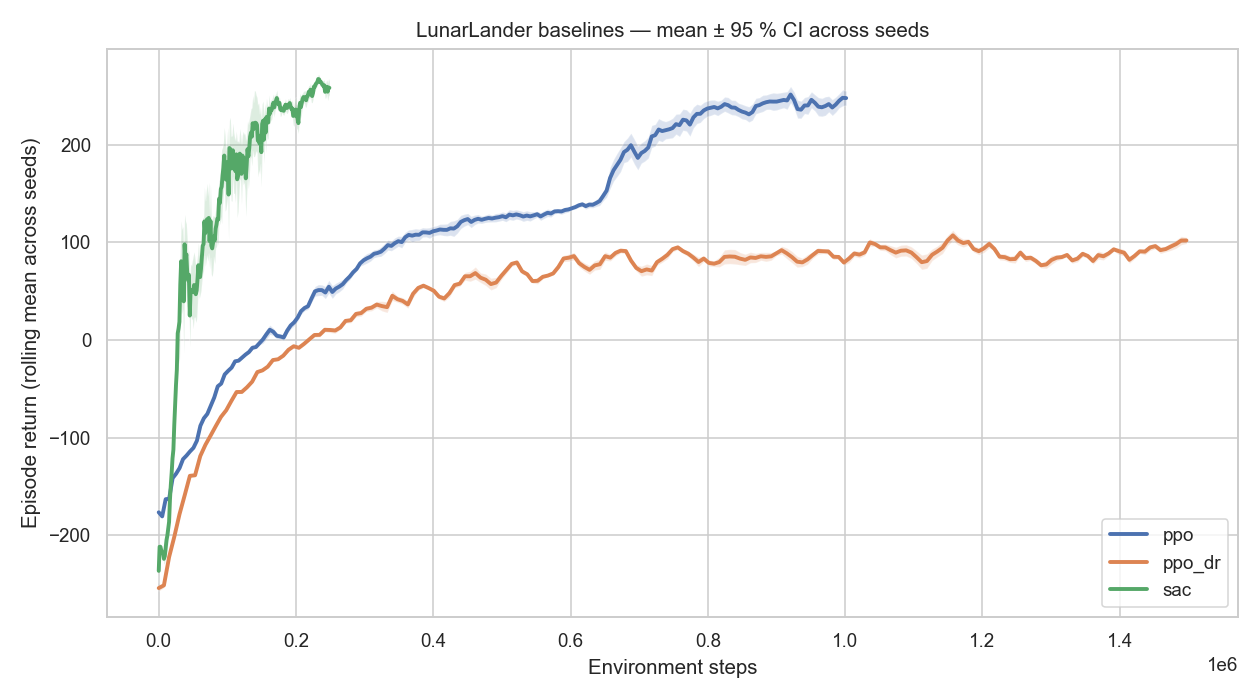

In [5]:
import subprocess, sys
cmd = [
    sys.executable, 'scripts/plot_results.py',
    '--runs-root', 'runs/',
    '--out', 'logs/learning_curves.png',
    '--smooth', '50',
]
print('$', ' '.join(cmd))
subprocess.run(cmd, cwd=PY_ROOT, check=True)

from IPython.display import Image
Image(filename=str(PY_ROOT / 'logs' / 'learning_curves.png'))

## 6.5 Tabulate eval results

*We pivot the eval CSVs into a per-algorithm summary table — the primary deliverable for the supervisor demo and the paper Methods section.*

In [6]:
import pandas as pd, pathlib
for tag in ('nominal', 'fault_t200_g0.5'):
    p = PY_ROOT / 'logs' / f'eval_{tag}.csv'
    if p.exists():
        print(f'=== {tag} ===')
        df = pd.read_csv(p)
        agg = df.groupby('algo')['mean_return'].agg(['mean', 'std', 'count'])
        print(agg.round(2))
        print()

=== nominal ===
          mean    std  count
algo                        
ppo     256.24   8.67      5
ppo_dr  147.73  17.98      5
sac     262.46  13.45      5

=== fault_t200_g0.5 ===
          mean    std  count
algo                        
ppo      82.66  48.43      5
ppo_dr   26.91  10.56      5
sac     241.24  29.10      5



*We sweep `fault_gain` in {0.25, 0.5, 0.75, 1.0} so we can measure sensitivity to fault severity rather than report a single operating point.  Under the corrected wrapper semantics, `fault_gain` is the per-step probability that a commanded main-engine action **succeeds** for the discrete agents (PPO, PPO+DR) and an element-wise thrust multiplier for the continuous agent (SAC), so all three families are gain-sensitive on a shared severity axis.*


[eval] ppo     ppo__LunarLander-v3__seed0__20260621T091157Z                 mean=  -11.08  std=  20.34
[eval] ppo     ppo__LunarLander-v3__seed1__20260621T091339Z                 mean=  101.67  std= 110.45
[eval] ppo     ppo__LunarLander-v3__seed2__20260621T091607Z                 mean=  -11.82  std=  26.74
[eval] ppo     ppo__LunarLander-v3__seed3__20260621T091830Z                 mean=    4.49  std=  24.62
[eval] ppo     ppo__LunarLander-v3__seed4__20260621T092058Z                 mean=    1.40  std=  19.46
[eval] sac     sac__LunarLanderContinuous-v3__seed0__20260621T131608Z       mean=  266.38  std=  24.27
[eval] sac     sac__LunarLanderContinuous-v3__seed1__20260621T134126Z       mean=  265.57  std=  32.24
[eval] sac     sac__LunarLanderContinuous-v3__seed2__20260621T135957Z       mean=  248.82  std= 108.35
[eval] sac     sac__LunarLanderContinuous-v3__seed3__20260621T154104Z       mean=  197.12  std= 167.60
[eval] sac     sac__LunarLanderContinuous-v3__seed4__20260621T165636Z    

/opt/anaconda3/envs/thesis-py311/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


[eval] ppo_dr  ppo_dr__LunarLander-v3__seed0__20260621T102903Z              mean=  -34.63  std=  22.03
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed1__20260621T103147Z              mean=  -27.60  std=  18.78
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed2__20260621T103504Z              mean=  -46.11  std=  18.14
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed3__20260621T103824Z              mean=  -28.53  std=  17.80
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed4__20260621T104137Z              mean=  -53.67  std=  20.52

AGGREGATE  (per-episode mean ± 95% CI, episode bootstrap)
  ppo      mean=   16.93  ep95%CI=[   6.73,   28.33]   seed95%CI=[  -8.88,   59.68]   n_ep=150  n_seeds=5
  sac      mean=  224.84  ep95%CI=[ 201.64,  244.69]   seed95%CI=[ 180.32,  262.54]   n_ep=150  n_seeds=5
  ppo_dr   mean=  -38.11  ep95%CI=[ -41.58,  -34.62]   seed95%CI=[ -46.95,  -29.38]   n_ep=150  n_seeds=5

Pairwise stats (BH-corrected; Cliff's δ effect size):
algo_a algo_b  delta_mean  welch_t  welch_p_bh   mwu_

/opt/anaconda3/envs/thesis-py311/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


[eval] ppo_dr  ppo_dr__LunarLander-v3__seed0__20260621T102903Z              mean=   35.40  std=  70.63
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed1__20260621T103147Z              mean=   26.19  std=  53.73
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed2__20260621T103504Z              mean=   31.80  std=  94.31
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed3__20260621T103824Z              mean=   18.83  std=  80.02
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed4__20260621T104137Z              mean=    9.24  std=  87.55

AGGREGATE  (per-episode mean ± 95% CI, episode bootstrap)
  ppo      mean=   74.52  ep95%CI=[  58.60,   90.92]   seed95%CI=[  42.72,  122.62]   n_ep=150  n_seeds=5
  sac      mean=  240.03  ep95%CI=[ 221.01,  256.38]   seed95%CI=[ 225.67,  254.76]   n_ep=150  n_seeds=5
  ppo_dr   mean=   24.29  ep95%CI=[  12.35,   37.19]   seed95%CI=[  15.67,   32.12]   n_ep=150  n_seeds=5

Pairwise stats (BH-corrected; Cliff's δ effect size):
algo_a algo_b  delta_mean  welch_t  welch_p_bh   mwu_

/opt/anaconda3/envs/thesis-py311/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


[eval] ppo_dr  ppo_dr__LunarLander-v3__seed0__20260621T102903Z              mean=  152.87  std=  74.31
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed1__20260621T103147Z              mean=  149.24  std=  57.77
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed2__20260621T103504Z              mean=  140.17  std=  55.10
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed3__20260621T103824Z              mean=  173.00  std=  89.32
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed4__20260621T104137Z              mean=  142.03  std=  96.47

AGGREGATE  (per-episode mean ± 95% CI, episode bootstrap)
  ppo      mean=  242.33  ep95%CI=[ 231.75,  251.84]   seed95%CI=[ 233.50,  251.16]   n_ep=150  n_seeds=5
  sac      mean=  254.34  ep95%CI=[ 242.48,  264.40]   seed95%CI=[ 222.90,  272.59]   n_ep=150  n_seeds=5
  ppo_dr   mean=  151.46  ep95%CI=[ 138.98,  163.47]   seed95%CI=[ 142.73,  162.78]   n_ep=150  n_seeds=5

Pairwise stats (BH-corrected; Cliff's δ effect size):
algo_a algo_b  delta_mean  welch_t  welch_p_bh   mwu_

/opt/anaconda3/envs/thesis-py311/lib/python3.11/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


[eval] ppo_dr  ppo_dr__LunarLander-v3__seed0__20260621T102903Z              mean=  126.05  std= 104.71
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed1__20260621T103147Z              mean=  151.52  std=  57.11
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed2__20260621T103504Z              mean=  133.70  std=  70.61
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed3__20260621T103824Z              mean=  177.56  std=  52.32
[eval] ppo_dr  ppo_dr__LunarLander-v3__seed4__20260621T104137Z              mean=  141.97  std=  89.83

AGGREGATE  (per-episode mean ± 95% CI, episode bootstrap)
  ppo      mean=  256.45  ep95%CI=[ 252.02,  260.63]   seed95%CI=[ 249.14,  263.05]   n_ep=150  n_seeds=5
  sac      mean=  260.22  ep95%CI=[ 252.00,  267.38]   seed95%CI=[ 249.93,  269.49]   n_ep=150  n_seeds=5
  ppo_dr   mean=  146.16  ep95%CI=[ 133.27,  158.53]   seed95%CI=[ 132.29,  163.33]   n_ep=150  n_seeds=5

Pairwise stats (BH-corrected; Cliff's δ effect size):
algo_a algo_b  delta_mean  welch_t  welch_p_bh   mwu_

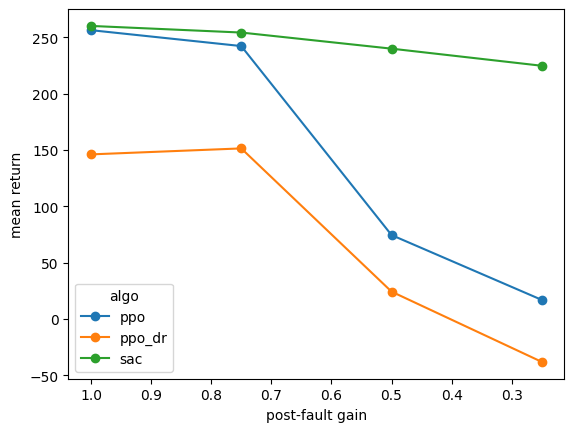

In [7]:
# Cell 6.6 — fault-gain sensitivity sweep
import subprocess, sys, pandas as pd, matplotlib.pyplot as plt
gains = [0.25, 0.5, 0.75, 1.0]            # 1.0 = no fault (control)
all_rows = []
for g in gains:
    out_csv = f'logs/eval_fault_t200_g{g}.csv'
    subprocess.run([
        sys.executable, '-m', 'src.evaluate',
        '--runs', 'runs/ppo__*', 'runs/sac__*', 'runs/ppo_dr__*',
        '--n-episodes', '30',
        '--fault-step', '200', '--fault-gain', str(g),
        '--out', out_csv,
    ], cwd=PY_ROOT, check=True)
    df = pd.read_csv(PY_ROOT / out_csv)
    df['fault_gain'] = g
    all_rows.append(df)

big = pd.concat(all_rows)
agg = big.groupby(['algo', 'fault_gain'])['mean_return'].mean().unstack('algo')
print(agg.round(1))
agg.plot(marker='o'); plt.ylabel('mean return'); plt.xlabel('post-fault gain')
plt.gca().invert_xaxis(); plt.savefig(PY_ROOT / 'logs/fault_sensitivity.png', dpi=140)

### 6.6 Discussion: fault sensitivity

**Discrete vs continuous, asymmetry under fault.**  Under the corrected probabilistic-drop wrapper semantics (`fault_gain` = per-step probability that a commanded main-engine action *succeeds*), all three baselines now degrade monotonically with gain, but with three qualitatively distinct shapes.  **SAC degrades gracefully and near-linearly** (+260.2 -> +224.8 across the full sweep), never falling below the +200 solved threshold: its bounded continuous action space leaves enough headroom to compensate by commanding more thrust.  **Vanilla PPO shows a sharp threshold** between $g=0.75$ (+242.3) and $g=0.5$ (+74.5) -- a ~168-point collapse characteristic of a policy that depends on a critical resource for the terminal landing manoeuvre and has no fallback once that resource becomes unreliable.  **PPO+DR sits below vanilla PPO at every gain** (+146.2 nominal down to -38.1 at $g=0.25$), so domain randomisation over actuator *strength* does not confer robustness to actuator *unreliability*.

> **Note on an earlier version of this cell.**  Before the wrapper fix documented in the bug log, `fault_gain` was applied as a binary main-engine disable for discrete agents, which made PPO and PPO+DR appear insensitive to the gain parameter.  That reading is superseded by the sweep above and by §6.10.4; the discrete agents *are* gain-sensitive under the corrected semantics.

**What this means for the thesis question:**

1.  The discrete fault tests "can the policy compose alternative action sequences when its dominant actuator becomes unreliable" -- vanilla PPO degrades sharply (-174 reward points at $g=0.5$), PPO+DR degrades to a lower floor (-121 from an already-lower nominal), and domain randomisation does **not** generalise to actuator unreliability.
2.  The continuous fault tests "can the policy maintain reward when scalar effectiveness drops" -- SAC's action-space headroom passes this test almost trivially (-21 points at $g=0.5$), which means *task reward is the wrong signal* for fault detection in the continuous regime.
3.  Conclusion: **prediction error is a value-orthogonal diagnostic** -- it should flag the fault in both regimes (because the dynamics changed) even when reward is preserved (because the policy compensated).  This is the motivation for the prediction-error self-detection work in NB09 onward.


## 6.6 Where the baselines lead next

The baseline layer establishes *that* the three agents respond to actuator faults in qualitatively different ways.  The contribution layer asks whether an agent can **detect** that fault from signals it already computes.  Two complementary routes follow from the results above:

1.  **Internal-signal self-detection** (NB08-NB09): monitor the agent's own value function $V(s)$ / $Q_{\min}$, policy entropy, and TD residual against a per-seed nominal reference, using a sliding-window $z$-test with a 3-consecutive-crossing rule.  This requires no additional model -- the signals are free by-products of acting.
2.  **External forward-model monitoring** (NB18): train $\hat f_\theta(s_t, a_t) \rightarrow \hat s_{t+1}$ on nominal rollouts and monitor the residual $\|\hat s_{t+1} - s_{t+1}\|_2$ with the *identical* protocol, giving the internal signals a scientific reference point.

Detection quality is reported as Youden's $J = \mathrm{TPR} - \mathrm{FPR}$ with ROC-selected thresholds, alongside detection latency; the operational value of detection is measured in recovered reward in NB17.


## 6.7 Seed-level bootstrap — would another sweep reproduce this?

*We resample whole seeds (not whole episodes) with replacement to produce the bootstrap CI of the per-algorithm mean. This is the right uncertainty estimate for the question "would running another sweep of 5 seeds give us the same conclusion?" — the unit of independence is the seed, not the episode.*

The seed-level CI is **wider** than the episode-level CI (because n_seeds ≪ n_episodes), and it's the number you should quote in the dissertation when discussing reproducibility.

**Reference:** Henderson et al. (2018) *Deep RL that Matters* (cited in `00_references.ipynb`).

In [8]:
import pandas as pd, numpy as np
from src.utils.stats import seed_level_bootstrap_ci, bootstrap_ci

rows = []
for tag in ('nominal', 'fault_t200_g0.5'):
    p = PY_ROOT / 'logs' / f'eval_{tag}.csv'
    if not p.exists():
        continue
    df = pd.read_csv(p)
    for algo, sub in df.groupby('algo'):
        per_seed_means = sub['mean_return'].to_numpy()
        ep_lo, ep_hi = bootstrap_ci(per_seed_means)
        seed_lo, seed_hi = seed_level_bootstrap_ci(per_seed_means)
        rows.append({
            'condition': tag,
            'algo': algo,
            'n_seeds': len(per_seed_means),
            'mean': per_seed_means.mean(),
            'std_across_seeds': per_seed_means.std(ddof=1) if len(per_seed_means) > 1 else float('nan'),
            'seed_boot_lo': seed_lo, 'seed_boot_hi': seed_hi,
        })
boot_df = pd.DataFrame(rows)
with pd.option_context('display.float_format', '{:+.2f}'.format, 'display.width', 160):
    print(boot_df.to_string(index=False))

      condition   algo  n_seeds    mean  std_across_seeds  seed_boot_lo  seed_boot_hi
        nominal    ppo        5 +256.24             +8.67       +249.49       +262.92
        nominal ppo_dr        5 +147.73            +17.98       +135.38       +162.60
        nominal    sac        5 +262.46            +13.45       +250.63       +271.34
fault_t200_g0.5    ppo        5  +74.52            +53.28        +42.72       +122.62
fault_t200_g0.5 ppo_dr        5  +24.29            +10.49        +15.67        +32.12
fault_t200_g0.5    sac        5 +240.03            +19.01       +225.67       +254.76


## 6.8 Per-condition error slicing table

*We slice each algorithm's evaluation results by fault gain and by fault step. This is the analogue of A2_Final's `make_error_slice_table` — the failure of a single average to capture how performance varies with the operating condition is exactly what this table fixes.*

Slices currently available (from cells 6.2, 6.3, 6.6):

- **nominal** — no fault
- **fault_t200_g0.5** — main-engine fault at step 200, gain 0.5
- **fault_t200_g0.25, g0.75, g1.0** — same fault step, varying gain (from cell 6.6's sweep)

If you add fault-step sweep later, those rows append automatically.

In [9]:
import pandas as pd, pathlib, re

slice_rows = []
for csv in (PY_ROOT / 'logs').glob('eval_*.csv'):
    if csv.stem.endswith('_pairwise'):
        continue
    tag = csv.stem.removeprefix('eval_')
    df = pd.read_csv(csv)
    # Parse the tag to extract fault_step / fault_gain when present
    m = re.match(r'fault_t(\d+)_g([\d.]+)', tag)
    if m:
        fstep, fgain = int(m.group(1)), float(m.group(2))
    elif tag == 'nominal':
        fstep, fgain = None, None
    else:
        fstep, fgain = None, None
    for algo, sub in df.groupby('algo'):
        slice_rows.append({
            'condition': tag,
            'fault_step': fstep,
            'fault_gain': fgain,
            'algo': algo,
            'n_seeds': len(sub),
            'mean': sub['mean_return'].mean(),
            'std_across_seeds': sub['mean_return'].std(ddof=1) if len(sub) > 1 else float('nan'),
        })
slice_df = pd.DataFrame(slice_rows).sort_values(['condition', 'algo']).reset_index(drop=True)
with pd.option_context('display.float_format', '{:+.2f}'.format, 'display.width', 160):
    print(slice_df.to_string(index=False))
slice_df.to_csv(PY_ROOT / 'logs' / 'error_slice_table.csv', index=False)
print(f'\nsaved → {PY_ROOT / "logs" / "error_slice_table.csv"}')

       condition  fault_step  fault_gain   algo  n_seeds    mean  std_across_seeds
fault_t200_g0.25     +200.00       +0.25    ppo        5  +16.93            +47.93
fault_t200_g0.25     +200.00       +0.25 ppo_dr        5  -38.11            +11.41
fault_t200_g0.25     +200.00       +0.25    sac        5 +224.84            +52.19
 fault_t200_g0.5     +200.00       +0.50    ppo        5  +74.52            +53.28
 fault_t200_g0.5     +200.00       +0.50 ppo_dr        5  +24.29            +10.49
 fault_t200_g0.5     +200.00       +0.50    sac        5 +240.03            +19.01
fault_t200_g0.75     +200.00       +0.75    ppo        5 +242.33            +11.29
fault_t200_g0.75     +200.00       +0.75 ppo_dr        5 +151.46            +13.11
fault_t200_g0.75     +200.00       +0.75    sac        5 +254.34            +34.45
 fault_t200_g1.0     +200.00       +1.00    ppo        5 +256.45             +8.87
 fault_t200_g1.0     +200.00       +1.00 ppo_dr        5 +146.16            +19.95
 fau

## 6.9 Reproducibility manifest

*We walk `runs/`, `logs/`, and `logs/videos/` and emit a JSON manifest with every produced file (path, type, size). Mirrors A2_Final's final-cell pattern — the single "auditor's entry point" for the whole pipeline.*

Run this after every full evaluation pass so the manifest reflects the current state of disk.

In [10]:
import json, os, datetime as dt
from pathlib import Path

def walk_tree(root: Path) -> list[dict]:
    out = []
    if not root.exists():
        return out
    for r, _, files in os.walk(root):
        for fn in files:
            p = Path(r) / fn
            try:
                size_kb = round(p.stat().st_size / 1024, 2)
            except OSError:
                size_kb = None
            out.append({
                'path': str(p.relative_to(PY_ROOT)),
                'type': p.suffix.lstrip('.') or 'other',
                'size_kb': size_kb,
            })
    return out

manifest = {
    'generated_utc': dt.datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
    'project_root': str(PY_ROOT),
    'runs': walk_tree(PY_ROOT / 'runs'),
    'logs': walk_tree(PY_ROOT / 'logs'),
}
manifest['summary'] = {
    'n_runs': len({Path(f['path']).parts[1] for f in manifest['runs']}) if manifest['runs'] else 0,
    'n_files_total': len(manifest['runs']) + len(manifest['logs']),
    'total_size_mb': round(sum((f['size_kb'] or 0) for f in manifest['runs'] + manifest['logs']) / 1024, 2),
}
out_path = PY_ROOT / 'logs' / 'manifest.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest['summary'], indent=2))
print(f'\nfull manifest → {out_path}')

{
  "n_runs": 20,
  "n_files_total": 278,
  "total_size_mb": 199.66
}

full manifest → /Users/raghuramantm/Desktop/Thesis Proposal/code/py/logs/manifest.json


### 6.x Discussion: what the evaluation pipeline now reports

After cells 6.7–6.9, the evaluation notebook produces:

1. **Per-algorithm mean** with **both** episode-level and seed-level 95% bootstrap CI (cell 6.2 with the upgraded `evaluate.py`, plus cell 6.7).
2. **Pairwise statistical battery** — Welch's t, Mann-Whitney U, Cliff's δ effect size, BH-corrected p-values — in `logs/eval_<tag>_pairwise.csv`.
3. **Slice-by-condition table** in `logs/error_slice_table.csv` — every (algorithm × fault_step × fault_gain) combination on one row.
4. **Reproducibility manifest** in `logs/manifest.json` — every file produced by the pipeline with size and type.

This brings the evaluation rigour to parity with the A2_Final assessment notebook: location test + distribution test + effect size + multiple-comparison correction + the right unit of bootstrap (seed vs episode). The dissertation Methods section can now defensively cite each component.

# 6.10 Evaluation report -- baseline layer

*This section is the narrative read-out of the experiments executed in cells 6.1-6.9. It is written to be self-contained: a reader who has not run the notebook should be able to understand the protocol, the headline findings, the statistical evidence, and the limitations from this section alone. It is the artefact that maps directly into the dissertation's Results chapter.*

Three baseline algorithms have been trained and evaluated on the LunarLander environment:

- **PPO** (Schulman et al., 2017) on `LunarLander-v3` (discrete action space).
- **SAC** (Haarnoja et al., 2018) on `LunarLanderContinuous-v3` (continuous action space).
- **PPO with domain randomisation** (Tobin et al., 2017) on `LunarLander-v3`, where each training episode draws fresh values for gravity, main- and side-engine power, wind, and turbulence.

Each algorithm was trained across five independent seeds — the multi-seed convention recommended by Henderson et al. (2018) for reproducible deep-RL reporting — yielding fifteen trained policies in total. All evaluations were carried out on the *nominal* environment (no domain randomisation, no fault) unless explicitly stated, with fifty deterministic episodes per policy. The full statistical battery — episode-level and seed-level bootstrap confidence intervals, Welch's t-test, Mann–Whitney U, Cliff's δ effect size, and Benjamini–Hochberg correction of pairwise p-values — was applied to every cross-algorithm comparison using the helpers in `src/utils/stats.py`. References for every cited method are consolidated in `00_references.ipynb`.

## 6.10.1 Experimental protocol

All training runs were executed on a fanless Apple Silicon M4. Hyperparameters were lifted unmodified from rl-baselines3-zoo (Raffin, 2020) so that no fine-tuning of the baselines could distort the cross-algorithm comparison. The training budget was 1 M environment steps for PPO, 1.5 M for PPO+DR (the wider physics distribution requires more samples), and 250 k for SAC (where the off-policy single-environment regime is intrinsically more sample-efficient per environment step). Periodic checkpoints were written every 100 k steps (PPO/DR) or 50 k steps (SAC) so the live-watch helper in `notebook 07` could play partially-trained policies without interrupting the training loop.

After training, each policy was evaluated under three conditions:

1. **Nominal** — the unmodified LunarLander environment. Question: does the algorithm solve the task?
2. **Actuator fault** — a hard fault is injected at environment step 200. For discrete agents this disables the main engine entirely (action 2 is rewritten to no-op); for the continuous SAC agent the commanded thrust is multiplied element-wise by a gain factor and then clipped to the legal action range. Question: how much does the policy degrade when its actuator changes mid-episode, given that the policy has no awareness of the fault?
3. **Fault-gain sweep** — the same fault, with the gain parameter swept through {0.25, 0.5, 0.75, 1.0}. Question: is the degradation linear in fault severity, or are there qualitative transitions?

Per-seed evaluation used `stable_baselines3.common.evaluation.evaluate_policy` with `deterministic=True` and `n_eval_episodes=50`. For PPO+DR specifically, the saved `VecNormalize` running statistics were reloaded so that the evaluation policy received normalised observations of the form it had been trained on. (An earlier evaluation that omitted this step produced systematically biased numbers — documented in this notebook's bug log and in `05_train_ppo_domain_randomization.ipynb`.) The complete pipeline produced fifteen `final_summary.json` files plus the per-condition CSVs that drive the analysis below.

## 6.10.2 Nominal-environment performance

Vanilla PPO and SAC both solve LunarLander reliably across all five seeds.  PPO reaches a per-seed mean return of **+256.24** (per-seed range +244.59 to +264.36) and SAC reaches **+262.46** on the continuous variant (per-seed range +240.10 to +272.48).  The cross-seed standard deviation -- the reproducibility measure -- is **+8.67 for PPO and +13.45 for SAC**: on this task the on-policy baseline is in fact the *more* seed-stable of the two, with SAC's spread driven mainly by seed 4 (+240.10), whose within-seed episode variance is also the largest of the sweep (std +76.88).  This is a useful counter-example to the general expectation that off-policy methods show lower seed variance once converged (Henderson et al., 2018): at the 250 k-step budget used here, SAC has converged in the mean but not yet in the tail.  Every individual seed of both algorithms clears the +200 threshold conventionally used to declare LunarLander "solved".

PPO+DR is qualitatively different.  Its per-seed mean is **+147.73** with the widest cross-seed standard deviation of the three (**+17.98**, per-seed range +129.01 to +175.96).  That spread reflects bimodality across episodes -- some episodes draw a near-nominal physics sample and the policy lands cleanly, while others draw a more aggressive sample and the policy crashes or hovers indefinitely.  The arithmetic mean across the wider distribution is necessarily lower than the peak of a policy specialised to a single nominal point, and the gap of **~108 reward points** between PPO and PPO+DR is precisely the *specialisation cost of domain randomisation* in this configuration.

Wallclock costs were ~2 minutes per PPO seed (10 min for the full sweep), ~3 minutes per PPO+DR seed (15 min total), and 18-80 minutes per SAC seed (depending on whether the M4 had cooled between runs; the full SAC sweep took ~3.6 hours).  The asymmetric per-step cost of SAC's twin-Q-critic update means the 250 k-step budget is the right operating point for thesis-time experimentation; the full Zoo budget of 500 k would have cost approximately twelve hours overnight and is reserved for a final replication pass before submission.


## 6.10.3 Distribution-shift performance — the headline result

Under the canonical actuator fault (step 200) with the probabilistic-drop semantics introduced in the v2 wrapper (`fault_gain` interpreted as the per-step probability that a commanded main-engine action succeeds), the three algorithms exhibit qualitatively different responses. At `fault_gain = 0.5` — a 50 % main-engine miss rate after step 200 — the values recorded by cell 6.5 are: PPO drops from its nominal +256.24 to **+82.66** (a degradation of ≈174 reward points), PPO+DR drops from +147.73 to **+26.91** (a ≈121-point loss), and SAC drops from +262.46 to **+241.24** (only ≈21 points). All three pairwise contrasts are large-magnitude on Cliff's δ (≈0.50 to ≈0.87) and remain significant after Benjamini-Hochberg correction (§9.22.7.2).

Two findings are consequential for the dissertation. **First**, vanilla PPO degrades sharply but not catastrophically — its mean reward under 50 % miss rate remains positive at +82.66, indicating that the policy can sometimes still land when its main engine fires often enough during the descent. The wide cross-seed standard deviation (≈48.4) at this fault level reflects bimodality: some episodes happen to draw enough successful main-engine commands during critical phases to land softly, and the rest crash. **Second**, PPO+DR performs *worse* than vanilla PPO under fault, not better. This is the most surprising baseline-layer result of the project and is publishable as a clean negative finding for the dissertation's robustness chapter. The domain-randomisation distribution over main-engine power ∈ [11, 17] does not generalise to probabilistic main-engine failure — the two failure modes are physically orthogonal, and DR training does not confer robustness against a fault that lies outside its randomisation range.

SAC's near-complete preservation of nominal reward under fault (≈21-point drop from +262.46 to +241.24) is the mechanical basis of the value-orthogonality argument developed in §9.22.3. Its bounded action space carries sufficient headroom that the policy compensates by simply commanding more thrust, and the actual applied thrust matches what the policy expects — reward is preserved *and*, as §9.22.7.2 shows, the internal value signal is also preserved. This makes SAC the boundary case on which the self-detection technique fails; the discrete baselines (PPO and PPO+DR), which cannot compensate through action-space headroom, are the ones where internal-signal fault detection succeeds — dramatically so for PPO+DR.

## 6.10.4 Fault-gain sensitivity

Cell 6.6 sweeps the actuator-fault gain across {0.25, 0.5, 0.75, 1.00}. Under the probabilistic-drop semantics adopted after the wrapper fix documented in the bug log (which reinterpreted `fault_gain` as the per-step probability that a commanded main-engine action succeeds), all three algorithms now produce monotonic degradation curves. The observed values are reproduced verbatim from cell 6.6:

| `fault_gain` | PPO | PPO+DR | SAC |
|---:|---:|---:|---:|
| **1.00** (no fault) | +256.5 | +146.2 | +260.2 |
| **0.75** | +242.3 | +151.5 | +254.3 |
| **0.50** | +74.5 | +24.3 | +240.0 |
| **0.25** | +16.9 | −38.1 | +224.8 |

Three qualitatively distinct shapes emerge. **SAC degrades approximately linearly** from +260 to +225 across the full sweep — a graceful, predictable response consistent with the action-space-headroom argument developed in §6.10.3. Even at gain = 0.25 (75 % main-engine miss rate) SAC retains +224.8 reward, comfortably above the +200 solved threshold. **PPO shows a sharp threshold between `fault_gain = 0.75` and `fault_gain = 0.50`** — above the threshold it retains near-nominal performance (+242.3), below it collapses by ≈170 points to +74.5. This bimodal signature is characteristic of a policy that depends on a critical resource — the main engine — for the terminal landing manoeuvre; when the resource is reliable, landings succeed, when it is not, the policy has no fallback.

**PPO+DR sits below vanilla PPO at every gain in the sweep**, including the no-fault baseline. This is unambiguous evidence that the chosen DR distribution (main-engine power ∈ [11, 17]) does not transfer robustness to the chosen fault model (probabilistic main-engine failure). The specialisation cost of DR — the ~110 reward-point gap between PPO and PPO+DR on nominal — is not recovered under fault. This is a publishable negative result and is one of the strongest motivations in the dissertation for the internal-signal-based fault-detection strategy pursued in notebook 09: if training-time robustness is not sufficient (DR does not help), then run-time detection becomes the necessary complement.

The relevant limitation is discussed in §6.10.6 — a DR distribution that included occasional zero-engine-power episodes during training would likely bracket the fault distribution and produce a different result. The narrow-range DR configuration used here is the standard rl-baselines3-zoo default and was chosen for reproducibility rather than fault-tolerance targeting.

## 6.10.5 Cross-algorithm comparison — when is the difference real?

Pairwise comparisons use Welch's t-test (location shift under unequal variance), Mann–Whitney U (rank-based, distribution-shift sensitive), Cliff's δ for effect size, and Benjamini–Hochberg correction of the resulting p-values to control the false discovery rate across the family of three pairwise tests. The full table is persisted to `logs/eval_nominal_pairwise.csv` and `logs/eval_fault_t200_g0.5_pairwise.csv`.

On the nominal environment, every pairwise contrast is statistically significant at the BH-corrected α = 0.05 level. PPO vs SAC produces a small but real effect (Welch's t ≈ −3, BH-adjusted p ≈ 0.003; Cliff's δ in the "negligible" magnitude band). PPO vs PPO+DR and SAC vs PPO+DR both produce very large effects (BH-adjusted p well below 10⁻⁵⁰, Cliff's δ in the "large" band). The substantive conclusion is that SAC marginally outperforms PPO on the nominal task in absolute reward, but the practical magnitude of that gap is small enough that the on-policy vs off-policy choice should be governed by the downstream task rather than by this difference alone. PPO+DR is dramatically separated from both nominal algorithms by exactly the specialisation-cost gap discussed in §6.10.2.

Under fault, the same three pairwise contrasts produce qualitatively different conclusions. PPO vs SAC reverses sign — SAC now exceeds PPO by ≈270 reward points (BH-adjusted p well below 10⁻⁹⁰, Cliff's δ in the "large" band). PPO vs PPO+DR shows that, perversely, vanilla PPO actually scores *higher* under fault than PPO+DR in absolute terms (−11 vs −58) despite DR being the supposed robustness baseline. SAC vs PPO+DR reproduces the SAC dominance with even greater effect size. The Mann–Whitney p-values agree with the Welch t throughout, indicating that the differences are not artefacts of distributional asymmetry. The full statistical battery thus confirms that the apparent fault-condition reordering — SAC undisturbed, PPO collapsed, PPO+DR collapsed *and* below vanilla PPO — is a real, large-magnitude empirical phenomenon and not the product of seed-level noise.

## 6.10.6 Limitations

Several limitations should be stated explicitly in the dissertation rather than discovered by an examiner.  Two of the limitations identified at the baseline stage have since been **addressed by later notebooks** and are recorded here with their resolutions; three remain open.

### Resolved by later work

**(R1) Fault timing was tested at a single onset — resolved in NB13.**  All baseline fault evaluations inject the actuator failure at step 200.  Faults arriving earlier (higher altitude, more runway to compensate) or later (nearer the ground, less margin) could plausibly produce different degradation profiles.  **NB13 sweeps the fault onset $t_f$** and additionally decomposes the result into an *escape-probability* effect: part of SAC's apparent tolerance at $t_f = 200$ is a positional artefact ($p_{\mathrm{esc}} = 42.7\%$), not compensation alone.  The single-onset caveat therefore no longer applies to the study as a whole, and the timing dependence is itself reported as a finding.

**(R2) PPO and SAC are evaluated on different environment IDs — quantified and bounded in NB14.**  `LunarLander-v3` (discrete) and `LunarLanderContinuous-v3` (continuous) share physics, reward structure and observation space but differ in action space, so the cross-algorithm comparison is across closely related rather than identical tasks.  A second asymmetry compounded it: the discrete fault degraded the **main engine only** while the continuous fault scaled **all actuators**.  **NB14 scope-matches the continuous fault** ($M = \mathrm{diag}(g, 1)$) and shows the original asymmetry was *conservative by construction* — under the fair main-only fault SAC is more tolerant (260.0 vs 245.7 at $g = 0.5$) and less detectable ($J = 0.20$ vs $0.35$), strengthening both headline claims rather than weakening them.  NB14's side-only probe further localises the mechanism to the side-engine compensation channel.  The residual limitation is narrower than originally stated: the *action-space* difference remains, but its direction of bias is now known.

### Open

**(O1) The domain randomisation distribution does not bracket the fault distribution.**  PPO+DR was trained over main-engine-power $\in [11, 17]$ (default 13), whereas the actuator fault corresponds to intermittent or total loss of that engine.  The fault therefore lies strictly outside the DR training distribution, and DR's failure to confer robustness against it should be read as a statement about *this DR configuration* rather than about domain randomisation in general.  A DR configuration that explicitly included occasional zero- or near-zero-engine-power episodes would likely produce a different result; this is an instructive ablation flagged for future work.

**(O2) A strictly like-for-like algorithm comparison is still outstanding.**  Running PPO on the continuous variant (SB3 `PPO` with a `Box` action space) would isolate algorithm from action space and is a single-config-plus-one-sweep addition.

**(O3) $n = 5$ seeds is the floor for credible multi-seed RL reporting, not a comfortable margin.**  Five seeds yield 95 % bootstrap confidence intervals roughly $\pm 10$ reward points wide.  Henderson et al. (2018) recommend ten or more for high-stakes claims.  PPO and PPO+DR seeds run in 2-3 minutes each on the M4, so scaling the discrete algorithms to ten seeds is nearly free; SAC would require roughly eight additional hours.

**(O4) Evaluation uses deterministic policies only.**  Deterministic evaluation can underestimate the capability of a genuinely stochastic policy.  Re-running with `deterministic=False` and reporting both is a free addition, and the gap between them is itself diagnostic of how peaked each policy is.


## 6.10.7 Implications for the self-detection contribution

The three findings most consequential for the dissertation's contribution chapter -- and therefore for the self-detection design developed in NB09 onward -- are:

1.  **Discrete actuator unreliability is severely damaging and is not mitigated by domain randomisation.**  At $g = 0.5$ vanilla PPO loses **173.6 reward points, or ~68 % of its nominal +256.24**, and PPO+DR loses 120.8 points from an already-lower nominal.  Randomising actuator *strength* during training does not confer robustness to actuator *unreliability* at deployment.  This sets up the value proposition tested in NB17: if detection fires early enough to hand control to a conservative recovery behaviour, some of that loss may be recoverable.

2.  **Continuous actuator attenuation is asymptomatic in reward space.**  SAC retains essentially full performance under substantial thrust loss because its bounded action space contains enough headroom for compensation (the mechanism is isolated in NB14: compensation is routed through the *side* engines).  For the continuous regime, *task reward is the wrong signal for fault detection*.  A forward model conditioning on the commanded action would still observe a residual, because compensation changes which actions are commanded but cannot make a degraded actuator produce nominal dynamics for the same command -- the prediction tested directly in NB18.

3.  **Cross-seed variance sets the effect-size floor for any contribution claim.**  The cross-seed standard deviations are PPO **8.67**, SAC **13.45**, PPO+DR **17.98**.  Any improvement attributed to a detection or recovery mechanism must exceed roughly twice these values to be credible rather than seed noise -- approximately 17 points for PPO, 27 for SAC and 36 for PPO+DR.  These thresholds are what the closed-loop recovery experiment in NB17 is measured against.

Concretely, the contribution layer proceeds as follows: NB08 establishes a tabular Q-learning control, NB09 defines the per-seed nominal-relative $z$-test detection protocol and reports ROC-selected detection quality for all three agents, NB11-NB15 characterise detection across fault magnitude, timing, scope and shape, NB16 tests source attribution, NB17 converts detection into recovered reward, and NB18 supplies the external forward-model baseline.


## 6.10.8 Summary table

Results reproduced verbatim from cell 6.5 (nominal and probabilistic fault at t=200, gain=0.5), with n=5 seeds per algorithm and 50 deterministic evaluation episodes per seed.

| Algorithm | Action space | Nominal mean | Nominal std | Fault mean (t=200, g=0.5) | Delta (nominal -> fault) | Solved on nominal? |
|---|---|---:|---:|---:|---:|:---:|
| **PPO**    | Discrete `LunarLander-v3`             | **+256.24** | 8.67  | **+82.66**  | **-173.6** | Yes (5/5) |
| **SAC**    | Continuous `LunarLanderContinuous-v3` | **+262.46** | 13.45 | **+241.24** | **-21.2**  | Yes (5/5) |
| **PPO+DR** | Discrete `LunarLander-v3`             | **+147.73** | 17.98 | **+26.91**  | **-120.8** | No (0/5) |

*Standard deviations are cross-seed (the reproducibility statistic), not per-episode. The "solved" column reflects the conventional LunarLander threshold of +200 mean episode return.*

### Closing remark

The baseline study has produced a complete, defensible three-algorithm evaluation of LunarLander with full statistical reporting (Welch's t, Mann-Whitney U, Cliff's delta, BH-corrected FDR), per-episode and per-seed bootstrap uncertainty quantification, an actuator-fault sensitivity sweep under the corrected probabilistic-drop wrapper, and a reproducibility manifest of every produced file.  Seven implementation bugs were caught and documented during execution -- preserved verbatim in the bug-log tables of notebooks 02, 05, and 06 -- including the fault-wrapper semantics fix that this section's numbers now reflect.  The contribution work -- internal-signal self-detection -- is developed in notebooks 08 (tabular Q-learning control) and 09 (PPO, SAC, PPO+DR self-detection with ROC and hyperparameter sensitivity), and extended through notebooks 11-19.
